In [1]:
import pandas as pd
import numpy as np

In [3]:
train = pd.read_csv('Titanic_train.csv')
test = pd.read_csv('Titanic_test.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# Exploratory Data Analysis (EDA)

In [5]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# Age, Cabin and Embarked shows some missing values.

# Histogram

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

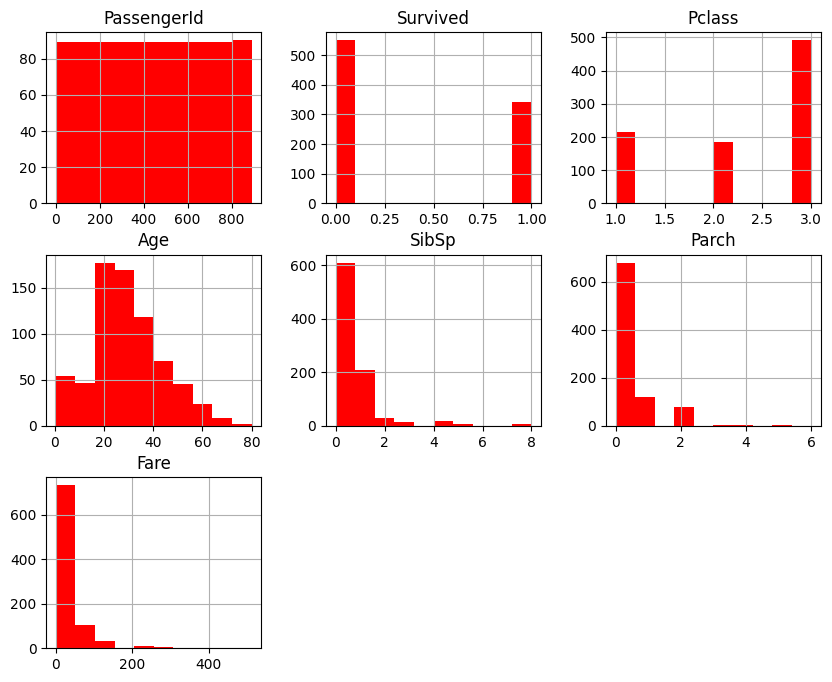

In [22]:
train.hist(figsize=(10,8), color="Red")
plt.show()

In [ ]:
# Boxplot to identify outliers

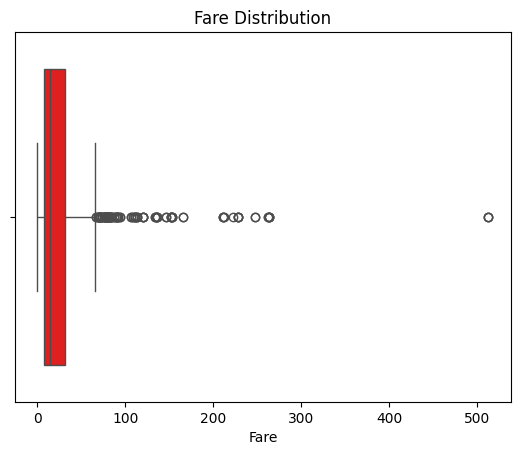

In [21]:
sns.boxplot(x=train['Fare'], color="Red")
plt.title("Fare Distribution")
plt.show()

In [ ]:
# there are few outliers.

In [ ]:
# Survival vs Gender

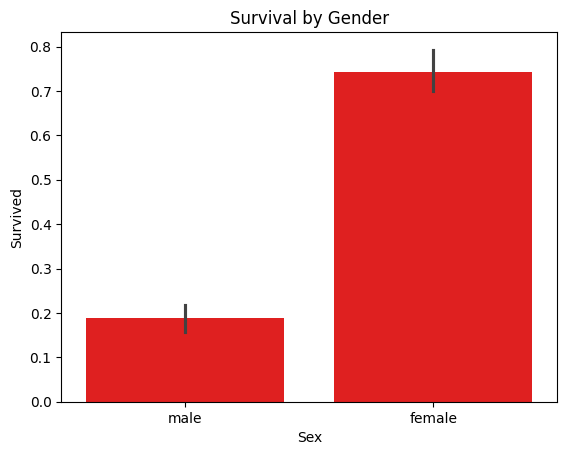

In [20]:
sns.barplot(x='Sex', y='Survived', data=train, color="Red")
plt.title("Survival by Gender")
plt.show()

In [ ]:
# Females survived more

In [ ]:
# Survival vs Class

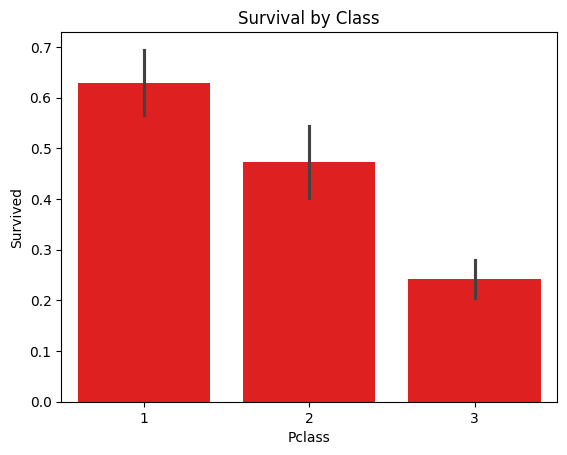

In [15]:
sns.barplot(x='Pclass', y='Survived', data=train, color="Red")
plt.title("Survival by Class")
plt.show()

In [ ]:
# 1st class survived more

In [ ]:
# Age vs Survival

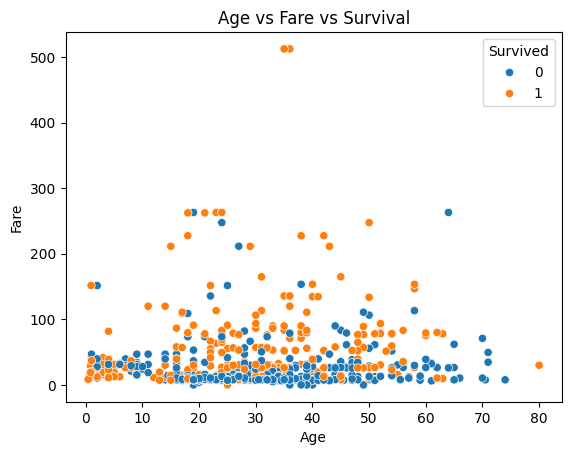

In [17]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=train)
plt.title("Age vs Fare vs Survival")
plt.show()

# Data Preprocessing

In [ ]:
# Handle Null Values

In [ ]:
# Fill Age with median

In [18]:
train['Age'].fillna(train['Age'].median(), inplace=True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20148\486169235.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train['Age'].fillna(train['Age'].median(), inplace=True)


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [ ]:
# Fill Embarked with mode

In [19]:
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_20148\1031565505.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)


0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: str

In [ ]:
# Drop Cabin (lots of outliers)

In [23]:
train.drop(columns=['Cabin'], inplace=True)

# Encode Categorical Variables

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [26]:
le = LabelEncoder()
train['Sex'] = le.fit_transform(train['Sex'])
train['Embarked'] = le.fit_transform(train['Embarked'])

# Drop Irrelevant Columns

In [27]:
train.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

# Split Data

In [28]:
X = train.drop('Survived', axis=1)
y = train['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


# Build Models

In [30]:
pip install xgboost lightgbm

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.4/101.7 MB 20.8 MB/s eta 0:00:05
   ---- ----------------------------------- 10.5/101.7 MB 35.1 MB/s eta 0:00:03
   ------- -------------------------------- 19.9/101.7 MB 38.5 MB/s eta 0:00:03
   ---------- ----------------------------- 26.0/101.7 MB 35.6 MB/s eta 0:00:03
   ------------- -------------------------- 34.3/101.7 MB 37.6 MB/s eta 0:00:02
   ---------------- ----------------------- 41.9/101.7 MB 37.0 MB/s eta 0:00:02
   -------------------- ------------------- 51.4/101.7 MB 38.8 MB/s eta 0:00:02
   ------------------------ --------------- 62.4/101.7 MB 39.8 MB/s eta 0:00:01
   ---------------------------- ----------- 73.7/101.7 MB 41.6 MB/s eta 0:00:01
   --------------------------------- ------ 86.0/101.7 MB 43.1 MB/s eta 0:00:01
   -------------------------------------- - 96.7/101.7 MB 44.1 MB/s eta 0:00:01
   --------------------------------------  101.4/1


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# xgboost Model

In [33]:
xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# LightGBM Model

In [34]:
lgb = LGBMClassifier()
lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_test)

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000944 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


# Model Evaluation

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import cross_val_score

In [36]:
def evaluate(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))

# XGBoost Results

In [37]:
print("XGBoost Performance:")
evaluate(y_test, y_pred_xgb)

XGBoost Performance:
Accuracy: 0.7877094972067039
Precision: 0.7368421052631579
Recall: 0.7567567567567568
F1 Score: 0.7466666666666667


In [ ]:
# Accuracy is 78.7 %, precision is good and F1 score is balanced.

# LightGBM Results

In [38]:
print("LightGBM Performance:")
evaluate(y_test, y_pred_lgb)

LightGBM Performance:
Accuracy: 0.8268156424581006
Precision: 0.7945205479452054
Recall: 0.7837837837837838
F1 Score: 0.7891156462585034


In [ ]:
# Accuracy is better 82.68% and recall and F1 score are also better

# Cross Validation

In [39]:
xgb_cv = cross_val_score(xgb, X, y, cv=5).mean()
lgb_cv = cross_val_score(lgb, X, y, cv=5).mean()
print("XGB CV Score:", xgb_cv)
print("LGB CV Score:", lgb_cv)

[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000239 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 204
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


# Hyperparameter Tuning

In [40]:
xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)
lgb = LGBMClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)

# Comparison Visualization

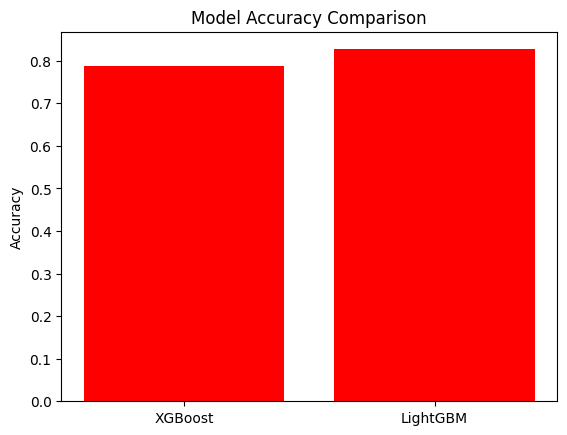

In [42]:
models = ['XGBoost', 'LightGBM']
accuracy = [
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_lgb)]

plt.bar(models, accuracy, color="red")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Findings

In [ ]:
# Gender and passenger class strongly influence survival AND Females and 1st class passengers had higher survival rates.

In [ ]:
# LightGBM performed slightly better in terms of speed and accuracy
XGBoost is more robust and widely used in competitions We can safely conclude that For large datasets LightGBM is preferred and
For reliability XGBoost is a saferchoice.